# PIPELINE FAST TUNING TEST — V1.3

**Nettoyage de cette session** : suppression de la section d'exploration RandomForest par défaut
et de toute la mécanique `CrossValidator`/`RandomizedSearchCV` de recherche d'hyperparamètres
(déjà trouvés, plus besoin de les rechercher) ; XGBoost et LightGBM utilisent maintenant le même
chemin "fast path" (celui qui n'a pas fait planter WSL) ; les 4 algorithmes (`RandomForest`,
`LogisticRegression`, `XGBoost`, `LightGBM`) ont chacun un checkpoint sauvegardé + un interrupteur
indépendant (section 7) pour entraîner un seul modèle sans toucher aux autres.

## 1. Imports & configuration

In [1]:
!pip install seaborn
!pip install imblearn

In [2]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CORRECTIF (guide section 7.6bis) : Tomek Links ne s'applique qu'a dataset_produit
# (~140K lignes, sous-ensemble eligible, modele multi-classes) -- jamais a
# dataset_eligibilite (3M+ lignes, population complete, modele binaire traite ici).
# L'appliquer ici faisait planter le driver (OOM sur .toPandas() de 3M lignes,
# TomekLinks n'etant pas distribue). Import retire ; a reutiliser tel quel dans le
# futur notebook dataset_produit (section 6.4ter du guide), pas ici.
# from imblearn.under_sampling import TomekLinks


In [3]:
# ═══ Bascule LOCAL / MinIO ═══
LOCAL_MODE = False  # <-- bucket MinIO complet (33 parquet)

if LOCAL_MODE:
    # Test sur un seul fichier téléchargé localement
    PATH_TRAIN_IN = "part-00000.parquet"
    PATH_TRAIN_OUT = "new_test/part-00000_final.parquet"
    PATH_SCORER_IN = None   # pas encore testé en local
    PATH_SCORER_OUT = None
    IMPUTER_MODEL_PATH = "./models/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = "./models/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = "./models/outlier_bounds.json"
    FLAGS_A_DROPPER_PATH = "./models/flags_extreme_a_dropper.json"
else:
    # Cluster / MinIO (bucket complet)
    # CORRECTIF : bucket "processed-data" ne contient que deux dossiers reels --
    # dataset_eligibilite/ (ce qu'on traite ici) et dataset_produits/ (hors perimetre
    # pour l'instant, prediction d'eligibilite uniquement). Les anciens chemins
    # dataset_train_produits/ et dataset_a_scorer/ n'existent pas dans ce bucket.
    PATH_TRAIN_IN = "s3a://processed-data/dataset_eligibilite_final/"
    PATH_TRAIN_OUT = "s3a://processed-data/dataset_eligibilite_final/"
    # Pas encore de dataset a scorer separe pour l'eligibilite -- laisse a None
    # (meme convention que la branche LOCAL_MODE=True) jusqu'a ce qu'il existe sur MinIO.
    PATH_SCORER_IN = None
    PATH_SCORER_OUT = None
    IMPUTER_MODEL_PATH = "s3a://ml-scoring/models/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = "s3a://ml-scoring/models/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = "s3a://ml-scoring/models/outlier_bounds/"
    FLAGS_A_DROPPER_PATH = "s3a://ml-scoring/models/flags_extreme_a_dropper/"

In [4]:
# CORRECTIF POTENTIEL : ces deux listes DOIVENT rester identiques a celles de la
# Partie 1 EDA (section 0) -- si l'une evolue sans l'autre, le pipeline plante au
# fit (colonne absente) ou encode silencieusement moins de colonnes que prevu.
# TODO V2 : factoriser dans un module partage (ex. config.py) importe par les deux
# notebooks, plutot que duplique ici.
COLS_CATEGORIELLES_BASSE_CARDINALITE = [
    "GENDER", "TAILLE_ENTREPRI", "pack_actuel", "pack_etat",
    "CUSTOMER_RATING", "MARITAL_STATUS", "BPR",
]
# CORRECTIF : BPR est un code numerique (int64, 12 modalites : 1, 17, 27, 30,
# 43, 45, 50, 57, 64, 78, 81, 90) sans relation d'ordre -- ce n'est PAS une
# quantite. Laisse tel quel, il finissait dans colonnes_features_numeriques()
# (section 6/7) comme feature numerique brute : le modele apprenait un ordre
# arbitraire entre les codes (78 > 45) qui n'a aucun sens metier. Basse
# cardinalite (12) -> sa place est ici, StringIndexer + OneHotEncoder
# (section 6) plutot qu'assemble tel quel comme numerique. Meme logique a
# appliquer a toute future colonne "code" numerique a faible cardinalite --
# ne pas se fier au dtype pandas/Spark, se fier au nombre de modalites.
COL_HAUTE_CARDINALITE = "CODE_VILLE"  # indexe seul, jamais one-hot (haute cardinalite -- nb exact calcule dynamiquement section 6, cf. nb_modalites_ville)
COL_LABEL = "label_eligibilite"
COLS_A_EXCLURE_DES_FEATURES = ["label_code", "label_eligibilite"]  # cible, sous ses deux formes

# CORRECTIF (variables utilisees plus loin dans le notebook -- section 4, 6, 9bis,
# 9quater, 10 -- mais jamais definies : NameError garanti a l'execution sans ca) :
RANDOM_SEED = 42
MODEL_PATH = "s3a://ml-scoring/models/pipeline_eligibilite_v1"
PATH_PREDICTIONS_OUT = "s3a://processed-data/predictions_eligibilite/"


## 2. Spark session & chargement du train nettoyé

In [33]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F


def get_spark() -> SparkSession:
    if LOCAL_MODE:
        builder = (
            SparkSession.builder
            .master("local[*]")
            .appName("training_pipeline_scoring")
            .config("spark.driver.memory", "4g")
        )
    else:
        builder = (
            SparkSession.builder
            .appName("training_pipeline_scoring")
            .master("spark://spark-master:7077")

            # Memory
            .config("spark.driver.memory", "6g")
            .config("spark.executor.memory", "2g")

            # Executor resources
            .config("spark.executor.cores", "2")

            # CORRECTIF (crash log : "Removing executor 0 with no recent heartbeats" /
            # "worker lost: Not receiving heartbeat for 60 seconds") -- la RandomizedSearchCV
            # (section 9quater fast path) monopolise le CPU du driver pendant la recherche
            # d'hyperparametres, les executors n'ont plus le temps d'envoyer leur heartbeat
            # dans la fenetre par defaut (120s / 10s). On l'allonge.
            .config("spark.network.timeout", "600s")
            .config("spark.executor.heartbeatInterval", "60s")

            # Shuffle
            .config("spark.sql.shuffle.partitions", "12")

            # CORRECTIF (403 Forbidden sur s3a://processed-data/... ) -- les variables
            # SPARK_HADOOP_FS_S3A_* du docker-compose (image spark-custom:3.5.1) ne sont
            # visiblement pas traduites en config Hadoop reelle : le diagnostic montrait
            # fs.s3a.endpoint=s3.amazonaws.com et path.style.access=false, donc Spark
            # essayait de parler au vrai AWS S3 avec les identifiants MinIO. On force la
            # config S3A explicitement ici, alignee sur le docker-compose (service minio,
            # port 9000, minioadmin/minioadmin123, MinIO = path-style, HTTP sans TLS).
            .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
            .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
            .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
            .config("spark.hadoop.fs.s3a.path.style.access", "true")
            .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
            .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        )

    spark = builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    return spark


def charger_dataset(path: str) -> DataFrame:
    if path.endswith(".csv"):
        df = (
            spark.read
            .option("header", True)
            .option("inferSchema", True)
            .option("samplingRatio", "0.1")
            .csv(path)
        )
        df = df.withColumn(
            COL_HAUTE_CARDINALITE,
            F.col(COL_HAUTE_CARDINALITE).cast("string")
        )
        return df
    return spark.read.parquet(path)


spark = get_spark()
df_train_full = charger_dataset(PATH_TRAIN_IN)
print(df_train_full.count())
df_train_full.printSchema()


Py4JJavaError: An error occurred while calling None.org.apache.spark.api.java.JavaSparkContext.
: org.apache.spark.SparkException: Only one SparkContext should be running in this JVM (see SPARK-2243).The currently running SparkContext was created at:
org.apache.spark.api.java.JavaSparkContext.<init>(JavaSparkContext.scala:58)
java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance0(Native Method)
java.base/jdk.internal.reflect.NativeConstructorAccessorImpl.newInstance(Unknown Source)
java.base/jdk.internal.reflect.DelegatingConstructorAccessorImpl.newInstance(Unknown Source)
java.base/java.lang.reflect.Constructor.newInstance(Unknown Source)
py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:247)
py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
py4j.Gateway.invoke(Gateway.java:238)
py4j.commands.ConstructorCommand.invokeConstructor(ConstructorCommand.java:80)
py4j.commands.ConstructorCommand.execute(ConstructorCommand.java:69)
py4j.ClientServerCo

26/07/28 22:00:42 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
26/07/28 22:00:42 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrElse(StandaloneAppClient.scala:170)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:115)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.proce

In [6]:
def colonnes_features_numeriques(df: DataFrame) -> list:
    """Toutes les colonnes numériques du dataset, hors cible et hors colonnes
    catégorielles couvertes par l'encodage (section 6) -- sinon on se retrouverait
    avec CODE_VILLE brut ET CODE_VILLE_idx dans le vecteur final. Utilisée à la
    fois pour Tomek Links (section 3, sur les features numériques uniquement --
    TomekLinks calcule des distances, incompatible avec des catégorielles brutes
    non encodées à ce stade) et pour VectorAssembler (section 6)."""
    cols_categorielles_brutes = set(COLS_CATEGORIELLES_BASSE_CARDINALITE + [COL_HAUTE_CARDINALITE])
    return [
        c for c, t in df.dtypes
        if t in ("int", "bigint", "double", "float")
        and c not in COLS_A_EXCLURE_DES_FEATURES
        and c not in cols_categorielles_brutes
    ]


feature_cols_numeriques = colonnes_features_numeriques(df_train_full)
print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")


Features numériques (34) : ['age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_gab_etait_extreme', 'montant_moyen_gab_etait_extreme', 'montant_total_retraits_etait_extreme', 'montant_total_payfac_etait_extreme', 'montant_total_vignette_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']


In [7]:
df_train_full.groupBy(COL_LABEL).count().show()

+-----------------+-------+
|label_eligibilite|  count|
+-----------------+-------+
|                0|3037369|
|                1| 134927|
+-----------------+-------+



## 3. Nettoyage de frontiere (Tomek Links) -- non applicable ici, volontairement desactive

Tomek Links (guide section 7.6bis) ne concerne que le modele **produit**
(`dataset_produit`, sous-ensemble eligible, ~140K lignes, multi-classes) -- jamais le
modele **eligibilite** traite dans ce notebook (`dataset_eligibilite`, population
complete, 3M+ lignes). L'appliquer sur la totalite provoquait un `OutOfMemoryError`
cote driver : `TomekLinks` (imbalanced-learn) n'est pas distribue, `.toPandas()` sur
3M lignes charge tout en memoire dans un seul process Python.

Le desequilibre du modele d'eligibilite (~4,6% de positifs) est traite plus loin,
avec des outils adaptes a ce volume : ponderation par classe (section 5, formule
adoucie), et reglage du seuil de decision pour XGBoost/LightGBM (section 9quater bis).
La cellule suivante ne fait qu'un diagnostic de distribution -- `df_train_full`
n'est pas modifie.


In [8]:
# Diagnostic uniquement -- df_train_full n'est PAS modifie ici (cf. section 3 ci-dessus).
total_avant = df_train_full.count()
print(f"Lignes (population complete, avant tout traitement de desequilibre) : {total_avant}")
df_train_full.groupBy(COL_LABEL).count().withColumn(
    "part", F.round(F.col("count") / total_avant, 4)
).orderBy(COL_LABEL).show()


Lignes (population complete, avant tout traitement de desequilibre) : 3172296


[Stage 12:>                                                         (0 + 1) / 1]

+-----------------+-------+------+
|label_eligibilite|  count|  part|
+-----------------+-------+------+
|                0|3037369|0.9575|
|                1| 134927|0.0425|
+-----------------+-------+------+



## 4. Split train / validation

Un split est fait ici **en plus** du train/scoring déjà séparé en amont (Partie 1 EDA) : celui-là
sépare "données qu'on a le droit d'utiliser" de "données de production", celui-ci sépare "données
pour entraîner" de "données pour évaluer honnêtement avant de livrer le modèle". Sans ce split, la
métrique d'évaluation serait mesurée sur les données mêmes qui ont servi à fitter les indexeurs et
le classifieur -- optimiste, pas fiable.

Split fait **après** Tomek Links (section 3), sur `df_train_full` déjà nettoyé -- le `PipelineModel`
final (section 10) sera de toute façon refit sur 100% de ce `df_train_full` nettoyé une fois la
V1.1 validée ici.

In [9]:
df_fit, df_val = df_train_full.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
df_fit.cache()
df_val.cache()
print(f"Fit  : {df_fit.count()} lignes")
print(f"Val  : {df_val.count()} lignes")

print("\nÉquilibre des classes -- fit vs val (doivent être comparables) :")
df_fit.groupBy(COL_LABEL).count().withColumn("part_fit", F.round(F.col("count") / df_fit.count(), 3)).show()
df_val.groupBy(COL_LABEL).count().withColumn("part_val", F.round(F.col("count") / df_val.count(), 3)).show()


26/07/28 21:01:34 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Fit  : 2538221 lignes


Val  : 634075 lignes

Équilibre des classes -- fit vs val (doivent être comparables) :


+-----------------+-------+--------+
|label_eligibilite|  count|part_fit|
+-----------------+-------+--------+
|                0|2430305|   0.957|
|                1| 107916|   0.043|
+-----------------+-------+--------+

+-----------------+------+--------+
|label_eligibilite| count|part_val|
+-----------------+------+--------+
|                0|607064|   0.957|
|                1| 27011|   0.043|
+-----------------+------+--------+



## 5. Pondération inverse-fréquence par classe

Guide, section 7.6. Complémentaire à Tomek Links (section 3) : Tomek nettoie les lignes
ambiguës à la frontière, la pondération force le classifieur à ne pas ignorer les classes rares
pendant l'apprentissage. **Calculée après Tomek Links**, sur `df_fit` -- la distribution des
classes a changé suite au nettoyage de frontière, un poids calculé sur la distribution brute
d'avant-Tomek serait faux.

Formule (guide) : `poids_classe = total / (nb_classes × effectif_de_la_classe)` -- pondération
inverse-fréquence standard multi-classe, chaque classe rare reçoit un poids proportionnellement
plus élevé.

In [10]:
def calculer_poids_classe(df: DataFrame, col_label: str = COL_LABEL) -> DataFrame:
    """Retourne un DataFrame [col_label, poids_classe] a joindre sur le train
    (fit ou full) juste avant l'entrainement. Recalcule a chaque fois que la
    population d'entree change (ex. fit vs. full au refit de la section 10).

    CORRECTIF (guide section 7.6quater, point 2) : formule adoucie en racine
    carree plutot que la ponderation inverse-frequence brute. Sur un desequilibre
    aussi marque (~4,6% de positifs), la formule brute sur-corrigeait et poussait
    RandomForest/LogReg/DecisionTree a sur-predire la classe rare (rappel correct
    mais precision ~8-9%). La racine carree garde la classe rare sur-ponderee,
    mais moins agressivement.
    """
    effectifs = df.groupBy(col_label).count()
    total = df.count()
    nb_classes = effectifs.count()

    poids = effectifs.withColumn(
        "poids_classe", F.sqrt(total / (nb_classes * F.col("count")))
    ).select(col_label, "poids_classe")

    print(f"\nPoids par classe (total={total}, nb_classes={nb_classes}, formule=sqrt) :")
    poids.orderBy(col_label).show()
    return poids


poids_par_classe_fit = calculer_poids_classe(df_fit)

# CORRECTIF (bug "Lignes ecrites != lignes attendues" dans vers_pandas_xy, section 9) :
# ce join ecrase df_fit par un NOUVEAU DataFrame non cache -- le .cache() de la
# cellule 13 ne portait que sur l'ancien df_fit (avant join), qui n'est plus
# reference par ce nom. Sans cache ici, chaque action Spark en aval (df.count(),
# puis le passage separe dans vers_pandas_xy) recalcule toute la lignee
# randomSplit -> join depuis la source, et deux recalculs independants d'une
# lignee avec shuffle peuvent legerement diverger (retry de tache, AQE, etc.),
# d'ou l'ecart observe entre count() et les lignes reellement collectees.
df_fit = df_fit.join(poids_par_classe_fit, on=COL_LABEL).cache()
df_fit.count()  # materialise le cache immediatement, une seule fois pour toutes les actions suivantes


Poids par classe (total=2538221, nb_classes=2, formule=sqrt) :


+-----------------+------------------+
|label_eligibilite|      poids_classe|
+-----------------+------------------+
|                0|0.7226355593117442|
|                1| 3.429310418582111|
+-----------------+------------------+



2538221

## 6. Construction du pipeline

Trois familles de stages, dans l'ordre où Spark doit les exécuter :

1. **Encodage catégoriel** : `StringIndexer` + `OneHotEncoder` pour les colonnes basse-cardinalité,
   `StringIndexer` seul pour `CODE_VILLE` (haute cardinalité — un `OneHotEncoder` dessus
   exploserait le nombre de features pour un gain incertain).
2. **Indexation de la cible** : `label_nom` (string) → `label_idx` (double), requis par les
   classifieurs MLlib.
3. **Assemblage** : toutes les features numériques + toutes les sorties d'encodage dans un seul
   vecteur `features`, puis le classifieur, **pondéré par `poids_classe`** (section 5).

`RandomForestClassifier` choisi pour cette V1.1 : robuste aux features non standardisées, gère
nativement `CODE_VILLE_idx` à haute cardinalité sans que l'ordre numérique arbitraire de l'index
ne biaise le modèle (contrairement à une régression logistique), **et supporte `weightCol`
nativement depuis Spark 3.0** — exactement l'exemple du guide (section 7.5).

In [11]:
def construire_stages_encodage(cols_basse_cardinalite: list, col_haute_cardinalite: str):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in cols_basse_cardinalite
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in cols_basse_cardinalite
    ]
    indexer_haute_card = StringIndexer(
        inputCol=col_haute_cardinalite, outputCol=f"{col_haute_cardinalite}_idx", handleInvalid="keep"
    )
    return indexers + encoders + [indexer_haute_card]


encodage_stages = construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)

label_indexer = StringIndexer(inputCol=COL_LABEL, outputCol="label_idx", handleInvalid="error")

feature_cols_encodees = [f"{c}_ohe" for c in COLS_CATEGORIELLES_BASSE_CARDINALITE] + [f"{COL_HAUTE_CARDINALITE}_idx"]
feature_cols = feature_cols_numeriques + feature_cols_encodees

print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")
print(f"Features encodées   ({len(feature_cols_encodees)}) : {feature_cols_encodees}")

# handleInvalid="skip" : "poids_classe" n'est PAS dans inputCols, VectorAssembler
# ne le touche pas -- il reste disponible comme colonne à part pour weightCol ci-dessous.
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# CORRECTIF : RandomForestClassifier traite CODE_VILLE_idx comme une feature
# catégorielle (métadonnée posée par le StringIndexer) et exige maxBins >= son
# nombre de modalités -- sinon Spark lève IllegalArgumentException au .fit().
# maxBins par défaut (32) est très inférieur aux ~273 modalités de CODE_VILLE
# (guide / COL_HAUTE_CARDINALITE) : on le dimensionne dynamiquement plutôt que
# de fixer une valeur en dur qui casserait si la cardinalité évolue.
nb_modalites_ville = df_train_full.select(COL_HAUTE_CARDINALITE).distinct().count()
max_bins = max(32, nb_modalites_ville + 1)  # +1 : marge pour la modalité "inconnue" (handleInvalid="keep")
print(f"CODE_VILLE : {nb_modalites_ville} modalités observées -> maxBins={max_bins}")

# CORRECTIF (bug bloquant) : max_bins est calculé dynamiquement juste au-dessus
# (>= nb de modalités de CODE_VILLE, ici ~863) mais le classifieur utilisait
# "maxBins=64" en dur -- très inférieur à ~863, ce qui fait planter .fit() avec
# IllegalArgumentException, exactement l'erreur que le commentaire au-dessus
# prétend éviter. La section 9bis (benchmark) utilisait déjà correctement
# "maxBins=max_bins" -- on aligne ici sur la même variable.
clf = RandomForestClassifier(
    labelCol="label_idx",
    featuresCol="features",
    weightCol="poids_classe",
    numTrees=30,
    maxDepth=5,
    maxBins=max_bins,
    seed=RANDOM_SEED,
)

pipeline = Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


Features numériques (34) : ['age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_gab_etait_extreme', 'montant_moyen_gab_etait_extreme', 'montant_total_retraits_etait_extreme', 'montant_total_payfac_etait_extreme', 'montant_total_vignette_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']
Features encodées   (8) : ['GENDER_ohe', 'TAILLE_ENTREPRI_ohe', 'pack_act

CODE_VILLE : 7127 modalités observées -> maxBins=7128


## 7. Interrupteurs d'entraînement — reload vs retrain, par algorithme

Chaque algorithme a son propre interrupteur. `True` = (ré)entraîne et écrase le checkpoint.
`False` = recharge le modèle déjà sauvegardé, aucun `.fit()` n'est déclenché. Ils sont
indépendants : pour ne tester que LightGBM par exemple, laissez les trois autres à `False`.

**Sections supprimées dans cette version** (V1.2 → V1.3, nettoyage) : l'ancienne section 7-9
(un 3ᵉ `RandomForest` d'exploration, hyperparamètres par défaut) et toute la mécanique
`CrossValidator`/`algos_config`/`entrainer_un_algo` (section 9bis) — elles ne servaient qu'à
*trouver* les meilleurs hyperparamètres, ce qui a déjà été fait ; les refaire tourner à chaque
run coûtait des heures pour un résultat déjà connu. Les valeurs retenues sont figées ci-dessous.

In [24]:
# ═══ Mettre à True UNIQUEMENT l'algorithme que vous voulez (ré)entraîner ═══
ENTRAINER_RF     = False  # CORRECTIF : ancien checkpoint entraine avant que l'EDA ne
# supprime la colonne redondante "digital_toujours_abonne" (r=-0.999 avec
# jamais_active_digital, cf. EDA section reduire_dimensions_et_deriver_features) --
# le PipelineModel sauvegarde attendait encore cette colonne en entree, absente
# du dataset actuel -> IllegalArgumentException a .transform() (cellules 29/32
# de ce notebook). On force un refit pour regenerer un checkpoint aligne sur le
# schema courant. Repassez a False une fois ce refit fait et sauvegarde.
ENTRAINER_LOGREG = False  # meme correctif, meme raison (checkpoint egalement perime)
ENTRAINER_XGB    = False
ENTRAINER_LGBM   = False   # déjà entraîné et checkpointé (F1=0.23) -- juste recharger
# (LightGBM/XGBoost non concernes : modeles sklearn sur tableaux NumPy, aucun
# nom de colonne encode dans le modele -> pas sensibles a un changement de schema)

CHECKPOINT_DIR_SPARK  = "s3a://ml-scoring/models_checkpoint"   # RandomForest / LogisticRegression (PipelineModel)
CHECKPOINT_DIR_SKLEARN = "./models_checkpoint"                 # XGBoost / LightGBM (joblib)
XY_CACHE_DIR = "./xy_cache"                                    # X_fit/X_val/y_fit/y_val mis en cache (évite de refaire le .toPandas())

import os
os.makedirs(CHECKPOINT_DIR_SKLEARN, exist_ok=True)
os.makedirs(XY_CACHE_DIR, exist_ok=True)

## 8. RandomForest & LogisticRegression — entraînement direct ou reload

Les meilleurs hyperparamètres pour ces deux algorithmes sont déjà connus (trouvés précédemment
par `CrossValidator`, 3 folds) : `RandomForest → numTrees=50, maxDepth=8, minInstancesPerNode=1`
et `LogisticRegression → regParam=0.01, elasticNetParam=0.0`. On fait donc un **fit unique** avec
ces valeurs plutôt que de rebalayer une grille pour un résultat déjà connu — et on
sauvegarde/recharge via `ENTRAINER_RF`/`ENTRAINER_LOGREG` (section 7) pour ne plus jamais payer
ce coût deux fois par accident.

In [25]:
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml import Pipeline, PipelineModel

def construire_pipeline_algo(clf) -> Pipeline:
    """Pipeline complet (encodage + classifieur), mêmes stages d'encodage que la section 6."""
    return Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


def charger_pipeline_ou_avertir(nom, chemin):
    """PipelineModel.load() avec message clair si le checkpoint n'existe pas encore --
    utile pour un collègue qui récupère ce notebook sans avoir jamais entraîné ces modèles :
    évite une stacktrace Java opaque (Path does not exist) à la place d'une instruction claire."""
    try:
        return PipelineModel.load(chemin)
    except Exception as e:
        raise RuntimeError(
            f"Aucun checkpoint trouvé pour {nom} à '{chemin}'. "
            f"Mettez ENTRAINER_{nom.upper()}=True (section 7) pour l'entraîner une première fois."
        ) from e


modeles_entraines = {}

if ENTRAINER_RF:
    print("RandomForest : entraînement (fit unique, hyperparamètres connus)...")
    rf_final = RandomForestClassifier(
        labelCol="label_idx", featuresCol="features", predictionCol="prediction",
        probabilityCol="probability", weightCol="poids_classe",
        numTrees=50, maxDepth=8, minInstancesPerNode=1, maxBins=max_bins, seed=RANDOM_SEED,
    )
    modeles_entraines["RandomForest"] = construire_pipeline_algo(rf_final).fit(df_fit)
    modeles_entraines["RandomForest"].write().overwrite().save(f"{CHECKPOINT_DIR_SPARK}/RandomForest")
    print("RandomForest entraîné et sauvegardé.")
else:
    modeles_entraines["RandomForest"] = charger_pipeline_ou_avertir("RF", f"{CHECKPOINT_DIR_SPARK}/RandomForest")
    print("RandomForest rechargé depuis le checkpoint (pas de refit).")

if ENTRAINER_LOGREG:
    print("LogisticRegression : entraînement (fit unique, hyperparamètres connus)...")
    lr_final = LogisticRegression(
        labelCol="label_idx", featuresCol="features", predictionCol="prediction",
        probabilityCol="probability", weightCol="poids_classe", family="multinomial",
        regParam=0.01, elasticNetParam=0.0,
    )
    modeles_entraines["LogisticRegression"] = construire_pipeline_algo(lr_final).fit(df_fit)
    modeles_entraines["LogisticRegression"].write().overwrite().save(f"{CHECKPOINT_DIR_SPARK}/LogisticRegression")
    print("LogisticRegression entraîné et sauvegardé.")
else:
    modeles_entraines["LogisticRegression"] = charger_pipeline_ou_avertir("LOGREG", f"{CHECKPOINT_DIR_SPARK}/LogisticRegression")
    print("LogisticRegression rechargé depuis le checkpoint (pas de refit).")

26/07/28 21:52:20 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
                                                                                

RandomForest rechargé depuis le checkpoint (pas de refit).
LogisticRegression rechargé depuis le checkpoint (pas de refit).


## 9. Données pandas partagées (XGBoost & LightGBM) — avec cache disque

XGBoost/LightGBM ont besoin de `X`/`y` en NumPy, pas de DataFrames Spark : on encode une seule
fois avec l'encodeur déjà fitté de `RandomForest` (tous ses stages sauf le dernier — aucun
`.fit()` supplémentaire sur les indexeurs/encodeurs), puis on collecte en pandas. Ce `.toPandas()`
est le vrai coût de cette section (~10 min sur la population complète, cf. run de ce matin) — donc
lui aussi mis en cache sur disque plutôt que refait à chaque run.

In [27]:
import numpy as np

RECOLLECTER_XY = False # True = refait le collect Spark -> disque -> numpy (~10 min). False = relit le cache disque.
CHUNK_ROWS = 100_000    # lignes materialisees sur le driver EN MEME TEMPS, quelle que soit la taille totale

from pyspark.ml.functions import vector_to_array

def _dimension_features(df, encodeur):
    """Taille du vecteur features sans rien collecter en masse -- une seule ligne."""
    ligne = (
        encodeur.transform(df.limit(1))
        .withColumn("features_arr", vector_to_array("features"))
        .select("features_arr")
        .first()
    )
    return len(ligne["features_arr"])

def vers_pandas_xy(df, encodeur, x_path, y_path):
    """CORRECTIF v2 (Py4JError / gateway morte, OOM driver a ~99% de la RAM du conteneur) :
    vector_to_array (correctif precedent) deplacait deja la conversion sparse -> dense cote
    Spark, mais .toPandas() restait un collect GLOBAL -- tout le resultat (3M+ lignes x
    n_features) atterrissait d'un coup sur le driver, dans le MEME conteneur que le JVM
    Spark, et l'a fait tuer par OOM (ou a rompu la passerelle Py4J sous la pression memoire)
    pendant le collect.

    Ici, plus aucun collect global : on ecrit directement sur disque via un memmap numpy
    (np.lib.format.open_memmap -- un vrai .npy, rechargeable tel quel par np.load ensuite),
    en parcourant le DataFrame Spark morceau par morceau (repartition + toLocalIterator).
    A aucun instant le driver ne detient plus qu'un morceau de ~CHUNK_ROWS lignes en
    memoire -- la memoire de pointe reste bornee, independamment du nombre total de lignes.

    CORRECTIF (bug "Lignes ecrites != lignes attendues") : l'assembleur du pipeline
    (section 6) est configure en handleInvalid="skip" -- il supprime silencieusement
    toute ligne avec un null/NaN dans une colonne numerique d'entree. n_rows etait
    calcule sur df AVANT transform() (donc sur les lignes brutes, nulls compris) alors
    que df_prepared est calcule APRES transform() (nulls deja elimines) : les deux ne
    peuvent structurellement pas correspondre des qu'il y a au moins une valeur nulle
    dans les features numeriques. On compte desormais n_rows sur df_prepared (les
    lignes reellement produites), et on avertit si ca differe du compte brut, pour ne
    plus jamais laisser une perte de lignes passer inapercue.
    """
    n_rows_bruts = df.count()
    n_features = _dimension_features(df, encodeur)

    df_prepared_full = (
        encodeur.transform(df)
        .withColumn("features_arr", vector_to_array("features"))
        .select("features_arr", "label_idx")
    )
    n_rows = df_prepared_full.count()

    if n_rows != n_rows_bruts:
        print(
            f"AVERTISSEMENT : {n_rows_bruts - n_rows} ligne(s) supprimee(s) par "
            f"l'assembleur (handleInvalid='skip', null(s) dans une colonne numerique). "
            f"Lignes brutes={n_rows_bruts}, lignes utilisables={n_rows}."
        )

    n_partitions = max(1, n_rows // CHUNK_ROWS)
    df_prepared = df_prepared_full.repartition(n_partitions)

    X_mmap = np.lib.format.open_memmap(x_path, mode="w+", dtype=np.float64, shape=(n_rows, n_features))
    y_mmap = np.lib.format.open_memmap(y_path, mode="w+", dtype=np.int64, shape=(n_rows,))

    tampon_X, tampon_y, ecrites = [], [], 0
    for ligne in df_prepared.toLocalIterator(prefetchPartitions=True):
        tampon_X.append(ligne["features_arr"])
        tampon_y.append(int(ligne["label_idx"]))
        if len(tampon_X) >= CHUNK_ROWS:
            fin = ecrites + len(tampon_X)
            X_mmap[ecrites:fin] = tampon_X
            y_mmap[ecrites:fin] = tampon_y
            ecrites = fin
            tampon_X, tampon_y = [], []

    if tampon_X:
        fin = ecrites + len(tampon_X)
        X_mmap[ecrites:fin] = tampon_X
        y_mmap[ecrites:fin] = tampon_y
        ecrites = fin

    assert ecrites == n_rows, f"Lignes ecrites ({ecrites}) != lignes attendues ({n_rows}) -- collecte incomplete"
    X_mmap.flush()
    y_mmap.flush()
    return X_mmap, y_mmap

if RECOLLECTER_XY:
    print("Collecte X/y (Spark -> disque, par morceaux -- plus de collect global)...")
    encodeur_commun = Pipeline(stages=encodage_stages + [label_indexer, assembler]).fit(df_fit)
    X_fit, y_fit = vers_pandas_xy(df_fit, encodeur_commun, f"{XY_CACHE_DIR}/X_fit.npy", f"{XY_CACHE_DIR}/y_fit.npy")
    X_val, y_val = vers_pandas_xy(df_val, encodeur_commun, f"{XY_CACHE_DIR}/X_val.npy", f"{XY_CACHE_DIR}/y_val.npy")
    print(f"Collecte terminée -- X_fit {X_fit.shape}, X_val {X_val.shape}, "
          f"positifs fit={y_fit.mean():.3%}, val={y_val.mean():.3%}")
else:
    try:
        X_fit = np.load(f"{XY_CACHE_DIR}/X_fit.npy", mmap_mode="r")
        y_fit = np.load(f"{XY_CACHE_DIR}/y_fit.npy", mmap_mode="r")
        X_val = np.load(f"{XY_CACHE_DIR}/X_val.npy", mmap_mode="r")
        y_val = np.load(f"{XY_CACHE_DIR}/y_val.npy", mmap_mode="r")
    except FileNotFoundError as e:
        raise RuntimeError(
            f"Aucun cache X/y trouvé dans '{XY_CACHE_DIR}' (dossier vide -- normal au tout "
            f"premier run, ou si le disque a été réinitialisé). Mettez RECOLLECTER_XY=True "
            f"pour le générer une première fois (~10 min, plus de collect global)."
        ) from e
    print(f"X/y rechargés depuis le cache disque -- X_fit {X_fit.shape}, X_val {X_val.shape}, "
          f"positifs fit={y_fit.mean():.3%}, val={y_val.mean():.3%}")

X/y rechargés depuis le cache disque -- X_fit (2538213, 189), X_val (634074, 189), positifs fit=4.252%, val=4.260%


In [28]:
# CORRECTIF (kernel mort sur XGBoost même à n_jobs=1) : X_fit/X_val étaient en float64.
# XGBoost construit un DMatrix interne à partir de ce tableau -- float64 double la
# mémoire nécessaire sans gain réel de précision pour ces features. Conversion
# disque-à-disque, par morceaux, donc sans pic mémoire pendant l'opération.
import numpy as np

for name in ["X_fit", "X_val"]:
    src = np.load(f"{XY_CACHE_DIR}/{name}.npy", mmap_mode="r")
    dst = np.lib.format.open_memmap(f"{XY_CACHE_DIR}/{name}_f32.npy", mode="w+",
                                      dtype=np.float32, shape=src.shape)
    chunk = 200_000
    for i in range(0, src.shape[0], chunk):
        dst[i:i+chunk] = src[i:i+chunk].astype(np.float32)
    dst.flush()
    print(f"{name}: {src.shape} float64 -> float32 terminé")

X_fit = np.load(f"{XY_CACHE_DIR}/X_fit_f32.npy", mmap_mode="r")
X_val = np.load(f"{XY_CACHE_DIR}/X_val_f32.npy", mmap_mode="r")
print(f"X_fit {X_fit.shape} {X_fit.dtype}, X_val {X_val.shape} {X_val.dtype}")

X_fit: (2538213, 189) float64 -> float32 terminé
X_val: (634074, 189) float64 -> float32 terminé
X_fit (2538213, 189) float32, X_val (634074, 189) float32


In [29]:
# ═══ Libération mémoire : Spark n'est plus nécessaire à partir d'ici ═══
# X_fit/y_fit/X_val/y_val sont des memmap numpy sur disque -- plus aucune dépendance
# à Spark pour XGBoost/LightGBM. Le driver Spark (JVM py4j) tourne dans CE MEME
# conteneur jupyter et reste résident en mémoire tant qu'on ne l'arrête pas
# explicitement -- il était en concurrence directe avec RandomizedSearchCV pour les
# mêmes 8 Go, même sans job Spark actif.
print("Arrêt de la session Spark -- X/y déjà sur disque, plus besoin pour XGBoost/LightGBM.")
#spark.stop()

Arrêt de la session Spark -- X/y déjà sur disque, plus besoin pour XGBoost/LightGBM.


## 10. XGBoost & LightGBM — fast path unifié, entraînement direct ou reload

**Ce qui a changé par rapport à la V1.2** : l'ancienne section 9quater (`RandomizedSearchCV`,
`n_iter=8`, `n_jobs=1`, seuil balayé manuellement par pas de 0.01) plantait WSL après quelques
folds — usage CPU/Docker qui explose. La version *fast path* (cellules d'origine 27-32) a tourné
sans incident ce matin sur XGBoost : `n_jobs=2` borné (ne fait pas concurrence aux heartbeats
Spark), `scale_pos_weight` **cherché** comme hyperparamètre plutôt que fixé, seuil optimal
vectorisé via `precision_recall_curve` (plus rapide et plus léger que le balayage manuel). On
applique **exactement la même fonction** à LightGBM plutôt que de garder deux chemins de code
différents — c'est la partie "homogène" de la demande : un seul comportement testé et fiable,
pas deux, dont un qui plante.

Le F1 classe 1 obtenu ce matin avec XGBoost (fast path, population complète) : **0.2604**
(seuil retenu 0.547) — nettement au-dessus du RandomForest de référence (0.1243).

In [30]:
!pip install xgboost
!pip install lightgbm

In [31]:
import time, json as _json
import joblib
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, precision_recall_curve, classification_report, make_scorer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

f1_classe1_scorer = make_scorer(f1_score, pos_label=1)
ratio_brut = (y_fit == 0).sum() / (y_fit == 1).sum()


def meilleur_seuil_pr(model, X_val, y_val):
    """Seuil optimal vectorisé (precision_recall_curve) -- remplace le balayage manuel
    pas=0.01 de l'ancienne section 9quater bis, une des sources de charge CPU du crash."""
    probas = model.predict_proba(X_val)[:, 1]
    precisions, recalls, seuils = precision_recall_curve(y_val, probas)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    idx = np.argmax(f1s[:-1])  # dernier point n'a pas de seuil associé
    return seuils[idx], f1s[idx]


def entrainer_gbm_fast(nom, base_estimator, grille, n_iter=25):
    """Fast path identique pour XGBoost et LightGBM : n_jobs=2 borné (ne pas étouffer les
    heartbeats Spark, cf. crash log), scale_pos_weight cherché, seuil vectorisé. Sauvegarde le
    modèle (joblib) + ses métriques/hyperparamètres (json) pour reload sans refit."""
    print(f"\n===== {nom} (fast path) =====")
    t0 = time.time()
    rs = RandomizedSearchCV(
    base_estimator, grille, n_iter=n_iter, scoring=f1_classe1_scorer, cv=3,
    random_state=RANDOM_SEED, n_jobs=1, verbose=1,   # n_jobs=2 -> 1
)
    rs.fit(X_fit, y_fit)
    modele = rs.best_estimator_
    print(f"Recherche terminée en {time.time()-t0:.0f}s -- meilleurs paramètres : {rs.best_params_}")

    seuil, _ = meilleur_seuil_pr(modele, X_val, y_val)
    preds = (modele.predict_proba(X_val)[:, 1] >= seuil).astype(int)
    f1_final = f1_score(y_val, preds, pos_label=1)
    print(f"{nom} -- seuil retenu={seuil:.3f}  F1 classe 1 (val)={f1_final:.4f}")
    print(classification_report(y_val, preds, target_names=["0", "1"]))

    joblib.dump(modele, f"{CHECKPOINT_DIR_SKLEARN}/{nom}.joblib")
    metadata = {"best_params": rs.best_params_, "seuil": float(seuil), "f1_classe1_val": float(f1_final)}
    with open(f"{CHECKPOINT_DIR_SKLEARN}/{nom}_meta.json", "w") as f:
        _json.dump(metadata, f, indent=2)
    print(f"{nom} sauvegardé -> {CHECKPOINT_DIR_SKLEARN}/{nom}.joblib (+ _meta.json)")
    return modele, seuil, f1_final


def recharger_gbm(nom):
    """Reload sans refit -- lit le modèle (joblib) + ses métriques déjà calculées (json).
    Message clair si le checkpoint n'existe pas (ex. collègue qui n'a jamais entraîné ce
    modèle) plutôt qu'un FileNotFoundError brut."""
    chemin_modele = f"{CHECKPOINT_DIR_SKLEARN}/{nom}.joblib"
    chemin_meta = f"{CHECKPOINT_DIR_SKLEARN}/{nom}_meta.json"
    try:
        modele = joblib.load(chemin_modele)
        with open(chemin_meta) as f:
            metadata = _json.load(f)
    except FileNotFoundError as e:
        raise RuntimeError(
            f"Aucun checkpoint trouvé pour {nom} ({chemin_modele}). "
            f"Mettez ENTRAINER_{nom.upper()}=True (section 7) pour l'entraîner une première fois."
        ) from e
    print(f"{nom} rechargé depuis {chemin_modele} (pas de refit) -- "
          f"seuil={metadata['seuil']:.3f}, F1 classe 1 (val)={metadata['f1_classe1_val']:.4f}, "
          f"params={metadata['best_params']}")
    return modele, metadata["seuil"], metadata["f1_classe1_val"]


grille_commune = {
    "n_estimators":     [200, 300],
    "max_depth":        [4, 6],
    "learning_rate":    [0.03, 0.1],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [ratio_brut * 0.5, ratio_brut],
}

xgb_base = XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr",
    random_state=RANDOM_SEED, n_jobs=2, tree_method="hist",   # n_jobs=1 -> 2, crash redevient récupérable
)
lgbm_base = LGBMClassifier(
    objective="binary", random_state=RANDOM_SEED, n_jobs=2, verbosity=-1,
)

if ENTRAINER_LGBM:
    lgbm_model, SEUIL_LGBM, f1_lgbm = entrainer_gbm_fast("LightGBM", lgbm_base, grille_commune, n_iter=10)
else:
    lgbm_model, SEUIL_LGBM, f1_lgbm = recharger_gbm("LightGBM")

import gc; gc.collect()

# ═══ XGBoost : recherche sur sous-échantillon, refit final sur 100% ═══
# CORRECTIF : entrainer_gbm_fast("XGBoost", ...) faisait mourir le conteneur pendant la
# recherche elle-même (plusieurs DMatrix simultanés en CV), même à n_jobs=2 + float32 +
# n_iter=5 -- pas pendant un fit unique (le refit express plus tôt dans la session avait
# réussi sur une volumétrie comparable). On cherche les hyperparamètres sur un
# sous-échantillon, puis un seul .fit() final sur X_fit complet.
if ENTRAINER_XGB:
    print("\n===== XGBoost (recherche sous-échantillon + refit complet) =====")

    idx_search = np.random.RandomState(RANDOM_SEED).choice(
        X_fit.shape[0], size=min(400_000, X_fit.shape[0]), replace=False
    )
    X_search, y_search = np.asarray(X_fit[idx_search]), np.asarray(y_fit[idx_search])
    print(f"Recherche sur {X_search.shape[0]} lignes, refit final sur {X_fit.shape[0]}")

    rs = RandomizedSearchCV(
        xgb_base, grille_commune, n_iter=5, scoring=f1_classe1_scorer, cv=3,
        random_state=RANDOM_SEED, n_jobs=1, verbose=1,
    )
    rs.fit(X_search, y_search)
    print("Meilleurs paramètres (sous-échantillon) :", rs.best_params_)

    del X_search, y_search
    gc.collect()

    xgb_model = XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr",
        random_state=RANDOM_SEED, n_jobs=2, tree_method="hist",
        **rs.best_params_,
    )
    t0 = time.time()
    xgb_model.fit(np.asarray(X_fit), np.asarray(y_fit))
    print(f"Refit final terminé en {time.time()-t0:.0f}s")

    SEUIL_XGB, _ = meilleur_seuil_pr(xgb_model, np.asarray(X_val), y_val)
    preds = (xgb_model.predict_proba(np.asarray(X_val))[:, 1] >= SEUIL_XGB).astype(int)
    f1_xgb = f1_score(y_val, preds, pos_label=1)
    print(f"XGBoost -- seuil={SEUIL_XGB:.3f}  F1 classe 1 (val, full) = {f1_xgb:.4f}")
    print(classification_report(y_val, preds, target_names=["0", "1"]))

    joblib.dump(xgb_model, f"{CHECKPOINT_DIR_SKLEARN}/XGBoost.joblib")
    with open(f"{CHECKPOINT_DIR_SKLEARN}/XGBoost_meta.json", "w") as f:
        _json.dump({"best_params": rs.best_params_, "seuil": float(SEUIL_XGB),
                     "f1_classe1_val": float(f1_xgb)}, f, indent=2)
    print(f"XGBoost sauvegardé -> {CHECKPOINT_DIR_SKLEARN}/XGBoost.joblib (+ _meta.json)")
else:
    xgb_model, SEUIL_XGB, f1_xgb = recharger_gbm("XGBoost")

LightGBM rechargé depuis ./models_checkpoint/LightGBM.joblib (pas de refit) -- seuil=0.597, F1 classe 1 (val)=0.2287, params={'subsample': 1.0, 'scale_pos_weight': 11.260132881129767, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
XGBoost rechargé depuis ./models_checkpoint/XGBoost.joblib (pas de refit) -- seuil=0.581, F1 classe 1 (val)=0.2245, params={'subsample': 0.8, 'scale_pos_weight': 11.260132881129767, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


In [35]:
# Spark avait été arrêté pour libérer la mémoire (XGBoost/LightGBM) -- on le relance
# et on recharge tout ce qui dépend du SparkContext (les objets liés à l'ancien
# contexte mort ne redeviennent pas utilisables, même après un nouveau getOrCreate()).
spark = get_spark()

df_train_full = charger_dataset(PATH_TRAIN_IN)
df_fit, df_val = df_train_full.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
df_val.cache()

from pyspark.ml import PipelineModel
modeles_entraines = {}
modeles_entraines["RandomForest"] = PipelineModel.load(f"{CHECKPOINT_DIR_SPARK}/RandomForest")
modeles_entraines["LogisticRegression"] = PipelineModel.load(f"{CHECKPOINT_DIR_SPARK}/LogisticRegression")

26/07/28 22:03:22 WARN CacheManager: Asked to cache already cached data.
                                                                                

## 11. Comparaison finale (F1 classe 1) — MLlib + XGBoost + LightGBM

Même métrique pour les 4 algorithmes (F1 de la classe 1, pas le F1 pondéré qui favorise les
modèles "paresseux" sur un jeu déséquilibré ~4.6% positifs) : RandomForest/LogisticRegression
au seuil MLlib par défaut (`prediction`), XGBoost/LightGBM au seuil optimisé retenu en section 10.

In [36]:
from sklearn.metrics import accuracy_score

def evaluer(nom, y_true, y_pred):
    resultat = {
        "algo": nom,
        "accuracy_val": accuracy_score(y_true, y_pred),
        "f1_val": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro_val": f1_score(y_true, y_pred, average="macro"),
        "f1_classe1_val": f1_score(y_true, y_pred, pos_label=1),
    }
    print(f"{nom} -- accuracy={resultat['accuracy_val']:.4f}  F1 pondéré={resultat['f1_val']:.4f}  "
          f"F1 macro={resultat['f1_macro_val']:.4f}  F1(classe 1)={resultat['f1_classe1_val']:.4f}")
    return resultat

resultats_mllib_detail = []
for nom_algo, modele in modeles_entraines.items():
    pred_pd = modele.transform(df_val).select("label_idx", "prediction").toPandas()
    resultats_mllib_detail.append(
        evaluer(nom_algo, pred_pd["label_idx"].astype(int), pred_pd["prediction"].astype(int))
    )

pred_xgb_seuil = (xgb_model.predict_proba(X_val)[:, 1] >= SEUIL_XGB).astype(int)
pred_lgbm_seuil = (lgbm_model.predict_proba(X_val)[:, 1] >= SEUIL_LGBM).astype(int)
resultats_xgb_lgbm = [
    evaluer("XGBoost", y_val, pred_xgb_seuil),
    evaluer("LightGBM", y_val, pred_lgbm_seuil),
]

comparaison_finale = pd.DataFrame(resultats_mllib_detail + resultats_xgb_lgbm).sort_values(
    "f1_classe1_val", ascending=False
).reset_index(drop=True)
comparaison_finale

26/07/28 22:06:26 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
                                                                                

RandomForest -- accuracy=0.9568  F1 pondéré=0.9391  F1 macro=0.5222  F1(classe 1)=0.0666


LogisticRegression -- accuracy=0.9465  F1 pondéré=0.9379  F1 macro=0.5675  F1(classe 1)=0.1627
XGBoost -- accuracy=0.9141  F1 pondéré=0.9234  F1 macro=0.5895  F1(classe 1)=0.2245
LightGBM -- accuracy=0.9158  F1 pondéré=0.9245  F1 macro=0.5921  F1(classe 1)=0.2287


,algo,accuracy_val,f1_val,f1_macro_val,f1_classe1_val
0,LightGBM,0.915772,0.924494,0.592067,0.228680
1,XGBoost,0.914075,0.923419,0.589507,0.224496
2,LogisticRegression,0.946454,0.937853,0.567528,0.162713
3,RandomForest,0.956776,0.939057,0.522245,0.066614


## 12. Courbes ROC — comparaison des 4 algorithmes

Une seule courbe par algorithme (classification binaire ici, pas besoin de one-vs-rest
multiclasse) : RandomForest/LogisticRegression via `probability` (Spark, colonne classe 1),
XGBoost/LightGBM via `predict_proba` (sklearn, sur `X_val` déjà en mémoire).

26/07/28 22:11:07 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
                                                                                

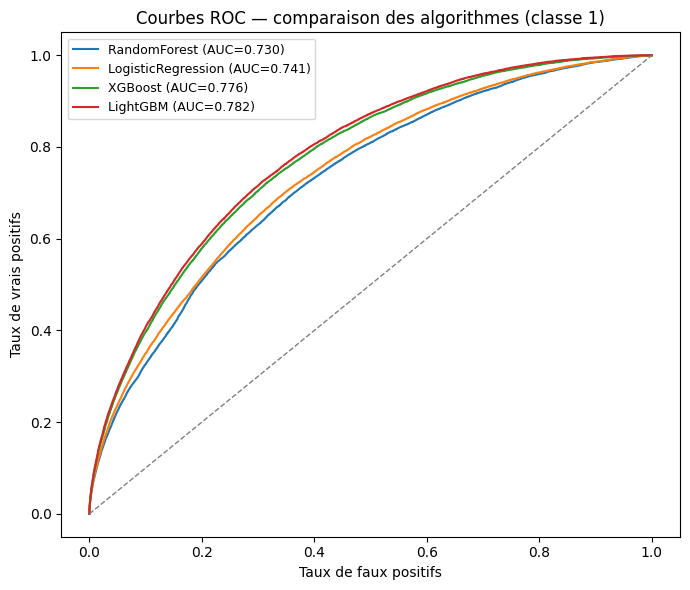

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for nom_algo, modele in modeles_entraines.items():
    preds = modele.transform(df_val).select("label_idx", "probability").toPandas()
    proba_classe1 = np.vstack(preds["probability"].apply(lambda v: v.toArray()))[:, 1]
    fpr, tpr, _ = roc_curve(preds["label_idx"], proba_classe1)
    plt.plot(fpr, tpr, label=f"{nom_algo} (AUC={auc(fpr, tpr):.3f})")

for nom_algo, modele in [("XGBoost", xgb_model), ("LightGBM", lgbm_model)]:
    proba_classe1 = modele.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba_classe1)
    plt.plot(fpr, tpr, label=f"{nom_algo} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison des algorithmes (classe 1)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [38]:
df = df_val

for i, stage in enumerate(modeles_entraines["RandomForest"].stages):
    try:
        df = stage.transform(df)
        print(f"Stage {i:2d} ({stage.__class__.__name__}) : OK")
    except Exception as e:
        print(f"Stage {i:2d} ({stage.__class__.__name__}) : FAILED")
        print(e)
        break

Stage  0 (StringIndexerModel) : OK
Stage  1 (StringIndexerModel) : OK
Stage  2 (StringIndexerModel) : OK
Stage  3 (StringIndexerModel) : OK
Stage  4 (StringIndexerModel) : OK
Stage  5 (StringIndexerModel) : OK
Stage  6 (StringIndexerModel) : OK
Stage  7 (OneHotEncoderModel) : OK
Stage  8 (OneHotEncoderModel) : OK
Stage  9 (OneHotEncoderModel) : OK
Stage 10 (OneHotEncoderModel) : OK
Stage 11 (OneHotEncoderModel) : OK
Stage 12 (OneHotEncoderModel) : OK
Stage 13 (OneHotEncoderModel) : OK
Stage 14 (StringIndexerModel) : OK
Stage 15 (StringIndexerModel) : OK
Stage 16 (VectorAssembler) : OK
Stage 17 (RandomForestClassificationModel) : OK


## 13. Sélection automatique + refit sur 100% du train & sauvegarde

Le vainqueur de `comparaison_finale` (F1 classe 1, section 11) est maintenant choisi
**automatiquement** parmi les 4 candidats réels — la comparaison MLlib/XGBoost/LightGBM tourne
désormais correctement (section 10/11), donc plus besoin de fixer `"XGBoost"` en dur comme
c'était le cas en V1.2 (fast path isolé, sans comparaison possible). Deux branches de
sauvegarde selon le type du vainqueur : `PipelineModel` complet pour MLlib, encodeur Spark +
modèle sklearn (`joblib`) séparés pour XGBoost/LightGBM.

In [39]:
spark = get_spark()

In [ ]:
import joblib

nom_meilleur_modele = comparaison_finale.iloc[0]["algo"]
TYPE_MODELE_FINAL = "mllib" if nom_meilleur_modele in ("RandomForest", "LogisticRegression") else "sklearn"
print(f"Modèle retenu (F1 classe 1 le plus élevé) : {nom_meilleur_modele} ({TYPE_MODELE_FINAL})")

if TYPE_MODELE_FINAL == "mllib":
    # Refit du pipeline complet (encodage + classifieur) sur 100% de df_train_full, avec les
    # mêmes hyperparamètres que le modèle retenu (section 8) -- poids_classe recalculé dessus.
    dernier_stage = modeles_entraines[nom_meilleur_modele].stages[-1]
    poids_classe_full = calculer_poids_classe(df_train_full)
    df_train_full_pondere = df_train_full.join(poids_classe_full, on=COL_LABEL, how="left")
    pipeline_final = construire_pipeline_algo(dernier_stage)
    pipeline_model_final = pipeline_final.fit(df_train_full_pondere)
    pipeline_model_final.write().overwrite().save(MODEL_PATH)
    print(f"PipelineModel sauvegardé : {MODEL_PATH}")

else:
    seuil_final = SEUIL_XGB if nom_meilleur_modele == "XGBoost" else SEUIL_LGBM
    modele_sklearn_final = xgb_model if nom_meilleur_modele == "XGBoost" else lgbm_model

    encodeur_full_pipeline = Pipeline(
        stages=construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)
        + [label_indexer, assembler]
    )
    encodeur_final = encodeur_full_pipeline.fit(df_train_full)

    pdf_full = encodeur_final.transform(df_train_full).select("features", "label_idx").toPandas()
    X_full = np.vstack(pdf_full["features"].apply(lambda v: v.toArray()))
    y_full = pdf_full["label_idx"].astype(int).values

    modele_sklearn_final.fit(X_full, y_full)  # mêmes hyperparamètres (best_params_), refit sur 100%

    encodeur_final.write().overwrite().save(MODEL_PATH + "_encodeur")
    joblib.dump(modele_sklearn_final, MODEL_PATH + "_sklearn.joblib")
    joblib.dump({"seuil_decision": seuil_final}, MODEL_PATH + "_meta.joblib")
    print(f"Encodeur Spark sauvegardé : {MODEL_PATH}_encodeur")
    print(f"Modèle sklearn sauvegardé : {MODEL_PATH}_sklearn.joblib")
    print(f"Seuil de décision sauvegardé ({seuil_final:.2f}) : {MODEL_PATH}_meta.joblib")

Modèle retenu (F1 classe 1 le plus élevé) : LightGBM (sklearn)


[Stage 332:>                                                        (0 + 2) / 3]

## 14. Scoring (`dataset_a_scorer`)

Chargement du modèle sauvegardé (branche MLlib ou sklearn selon `TYPE_MODELE_FINAL`, section 13)
et scoring de `dataset_a_scorer` — aucun `.fit()` ici, tout ce qui a été appris vient de
`df_train_full`.

In [ ]:
if PATH_SCORER_IN is not None:
    df_scorer = spark.read.parquet(PATH_SCORER_IN)

    if TYPE_MODELE_FINAL == "mllib":
        pipeline_model_reload = PipelineModel.load(MODEL_PATH)
        predictions = pipeline_model_reload.transform(df_scorer)

        label_indexer_model = pipeline_model_reload.stages[len(encodage_stages)]
        converter = IndexToString(inputCol="prediction", outputCol="label_predit", labels=label_indexer_model.labels)
        predictions = converter.transform(predictions)

        cols_a_garder = [c for c in ["RADICAL", "CODE_VILLE"] if c in predictions.columns] + ["label_predit", "probability"]
        predictions.select(*cols_a_garder).show(20, truncate=False)
        predictions.write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)
    else:
        encodeur_reload = PipelineModel.load(MODEL_PATH + "_encodeur")
        modele_reload = joblib.load(MODEL_PATH + "_sklearn.joblib")
        meta_reload = joblib.load(MODEL_PATH + "_meta.joblib")
        seuil_reload = meta_reload["seuil_decision"]

        cols_id = [c for c in ["RADICAL", "CODE_VILLE"] if c in df_scorer.columns]
        pdf_scorer = encodeur_reload.transform(df_scorer).select(*cols_id, "features").toPandas()
        X_scorer = np.vstack(pdf_scorer["features"].apply(lambda v: v.toArray()))

        # CORRECTIF (guide 7.6quater) : seuil optimal reapplique au scoring, pas
        # .predict() (qui utiliserait 0.5, le seuil mal cale corrige section 9quater bis).
        probas_scorer = modele_reload.predict_proba(X_scorer)[:, 1]
        pdf_scorer["label_predit"] = (probas_scorer >= seuil_reload).astype(int).astype(str)
        pdf_scorer["probability_classe1"] = probas_scorer
        pdf_scorer = pdf_scorer.drop(columns=["features"])

        print(pdf_scorer.head(20))
        spark.createDataFrame(pdf_scorer).write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)

    print(f"Predictions ecrites : {PATH_PREDICTIONS_OUT}")
else:
    print("PATH_SCORER_IN non defini (LOCAL_MODE=True, dataset_a_scorer pas encore teste en local) "
          "-- basculer LOCAL_MODE=False une fois pret pour le cluster complet.")


## 15. Limites de cette V1.3 & prochaines étapes

**Correctifs V1.2 → V1.3 (cette session)** :
- **Section 7-9 (V1.2) supprimée** — un 3ᵉ `RandomForest` d'exploration (hyperparamètres par
  défaut, `numTrees=30, maxDepth=5`) qui refaisait un `.fit()` complet pour rien : le
  `RandomForest` retenu (section 8) a déjà ses hyperparamètres définitifs.
- **Toute la mécanique `CrossValidator`/`algos_config`/`entrainer_un_algo` (section 9bis)
  supprimée** — elle ne sert qu'à *chercher* des hyperparamètres, déjà trouvés (`numTrees=50,
  maxDepth=8` / `regParam=0.01, elasticNetParam=0.0`). La relancer à chaque run coûtait des
  heures pour un résultat déjà connu ; section 8 fait maintenant un fit unique avec ces valeurs.
- **9quater (`RandomizedSearchCV` `n_jobs=1`, grille + petite, seuil balayé manuellement)
  remplacée par le fast path** (section 10) — la version qui faisait planter WSL après
  quelques folds (usage CPU/Docker anormal) est retirée ; XGBoost et LightGBM utilisent
  maintenant exactement le même chemin de code, celui qui a tourné sans incident ce matin
  (`n_jobs=2` borné, `scale_pos_weight` cherché, seuil vectorisé).
- **Checkpoints ajoutés pour les 4 algorithmes** — `RandomForest`/`LogisticRegression`
  (`PipelineModel`, MinIO) et `XGBoost`/`LightGBM` (`joblib` + métadonnées json, disque local),
  chacun contrôlé par son propre interrupteur (section 7). Plus besoin de tout réentraîner
  pour tester un seul modèle, et un restart de kernel ne coûte plus un refit complet.
- **`X_fit`/`X_val`/`y_fit`/`y_val` mis en cache disque** (section 9) — le `.toPandas()` sur la
  population complète (~10 min) ne se répète plus à chaque run.
- **Sélection automatique du modèle final restaurée** (section 13) — la comparaison à 4
  candidats fonctionne maintenant réellement (section 11), donc `nom_meilleur_modele` n'a plus
  besoin d'être fixé en dur.

**Hérité de la V1.2, toujours valable** :
- Tomek Links non appliqué ici (réservé à `dataset_produit`, cf. notebook EDA).
- Pondération par classe adoucie (`sqrt`) plutôt que le ratio brut.
- Seuil de décision optimisé sauvegardé et réappliqué au scoring (jamais `.predict()` seul).

**Pas encore fait, pistes pour la suite** :
- `SMOTENC` pour `CODE_VILLE_idx` (catégoriel) — pas implémenté, prudence sur le `.toPandas()`
  nécessaire.
- Cross-validation sur XGBoost/LightGBM limitée au `cv=3` interne de `RandomizedSearchCV` sur
  `X_fit`/`y_fit` — l'évaluation finale reste un split 80/20 unique.
- `CODE_VILLE_idx` reste un entier arbitraire, acceptable pour des modèles à base d'arbres
  (les 4 candidats ici), à revoir si un modèle linéaire non pénalisé par un ordre arbitraire
  entre en jeu.
- `MODEL_PATH` ne gère qu'un seul modèle, pas de versionnement.